In [1]:
import json
import warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_extraction import DictVectorizer
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, RocCurveDisplay
)

warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({
    'figure.figsize': (12, 6),
    'font.size': 11,
    'axes.titlesize': 14,
    'axes.labelsize': 12,
})

COLORS = {
    'explicit': '#3498db',
    'ngram': '#e74c3c', 
    'lstm': '#27ae60',
    'human': '#9b59b6',
    'ai': '#f39c12'
}

PROJECT_ROOT = Path('..').resolve()
REAL_DIR = PROJECT_ROOT / 'data' / 'real'
ARTIFICIAL_DIR = PROJECT_ROOT / 'data' / 'artificial'

SEED = 42
np.random.seed(SEED)


### 1. Data loading & feature extraction

In [2]:
def load_all_charts(base_dir: Path, label: int) -> list[dict]:
    charts = []
    for dataset in ['fraxtil', 'itg']:
        dataset_dir = base_dir / dataset
        if not dataset_dir.exists():
            continue
        for json_path in dataset_dir.glob('*.json'):
            with open(json_path, 'r') as f:
                data = json.load(f)
            song_name = data.get('song_name', json_path.stem)
            for diff_name, chart_data in data.get('charts', {}).items():
                steps = chart_data.get('steps', [])
                if len(steps) < 10:
                    continue
                charts.append({
                    'song_name': song_name,
                    'dataset': dataset,
                    'difficulty': diff_name,
                    'steps': steps,
                    'label': label
                })
    return charts

human_charts = load_all_charts(REAL_DIR, label=0)
ai_charts = load_all_charts(ARTIFICIAL_DIR, label=1)
all_charts = human_charts + ai_charts

songs = list(set(c['song_name'] for c in all_charts))
np.random.shuffle(songs)
n_train = int(len(songs) * 0.8)
train_songs, test_songs = set(songs[:n_train]), set(songs[n_train:])

train_charts = [c for c in all_charts if c['song_name'] in train_songs]
test_charts = [c for c in all_charts if c['song_name'] in test_songs]
y_train = np.array([c['label'] for c in train_charts])
y_test = np.array([c['label'] for c in test_charts])

display(Markdown(f"Dataset: {len(all_charts)} charts ({len(human_charts)} human, {len(ai_charts)} AI) from {len(songs)} songs"))
display(Markdown(f"Split: {len(train_charts)} train / {len(test_charts)} test"))


Dataset: 2195 charts (1094 human, 1101 AI) from 222 songs

Split: 1748 train / 447 test

In [3]:
def compute_entropy(probs):
    probs = np.array([p for p in probs if p > 0])
    return -np.sum(probs * np.log2(probs)) if len(probs) > 0 else 0

def extract_explicit_features(chart):
    steps = chart['steps']
    times = np.array([s['time'] for s in steps])
    patterns = [s['step'] for s in steps]
    
    duration = times[-1] - times[0]
    delta_times = np.diff(times)
    delta_times = delta_times[delta_times > 0]
    
    if len(delta_times) == 0 or duration <= 0:
        return None
    
    n_steps = len(patterns)
    holds = sum(1 for p in patterns if '2' in p or '3' in p)
    jumps = sum(1 for p in patterns if p.count('1') >= 2)
    repeats = sum(1 for i in range(1, len(patterns)) if patterns[i] == patterns[i-1])
    
    arrow_counts = [0, 0, 0, 0]
    for p in patterns:
        for i, c in enumerate(p):
            if c in '123':
                arrow_counts[i] += 1
    total_arrows = sum(arrow_counts) or 1
    
    return [
        n_steps / duration,
        np.mean(delta_times), 
        np.std(delta_times),
        holds / n_steps,
        jumps / n_steps,
        len(set(patterns)) / n_steps,
        repeats / (n_steps - 1) if n_steps > 1 else 0,
        compute_entropy([c / total_arrows for c in arrow_counts]),
    ]

EXPLICIT_FEATURE_NAMES = [
    'steps_per_second', 'mean_delta', 'std_delta', 'hold_ratio',
    'jump_ratio', 'unique_pattern_ratio', 'repeat_ratio', 'arrow_entropy'
]

X_train_explicit = np.array([f for c in train_charts if (f := extract_explicit_features(c)) is not None])
X_test_explicit = np.array([f for c in test_charts if (f := extract_explicit_features(c)) is not None])

scaler_explicit = StandardScaler()
X_train_explicit_scaled = scaler_explicit.fit_transform(X_train_explicit)
X_test_explicit_scaled = scaler_explicit.transform(X_test_explicit)

display(Markdown(f"{len(EXPLICIT_FEATURE_NAMES)} hand-crafted features"))


8 hand-crafted features

In [4]:
def extract_ngram_features(chart, timing_bins=20):
    steps = chart['steps']
    patterns = [s['step'] for s in steps]
    times = [s['time'] for s in steps]
    
    features = {}
    
    unigram_counts = Counter(patterns)
    total = len(patterns)
    for pattern, count in unigram_counts.items():
        features[f'uni_{pattern}'] = count / total
    
    bigrams = list(zip(patterns[:-1], patterns[1:]))
    bigram_counts = Counter(bigrams)
    total_bigrams = len(bigrams) or 1
    for (p1, p2), count in bigram_counts.items():
        features[f'bi_{p1}_{p2}'] = count / total_bigrams
    
    if len(times) > 1:
        deltas = np.diff(times)
        deltas = deltas[deltas > 0]
        if len(deltas) > 0:
            hist, _ = np.histogram(deltas, bins=timing_bins, range=(0, 2), density=True)
            for i, val in enumerate(hist):
                features[f'dt_bin_{i}'] = val
    
    return features

train_ngram_features = [extract_ngram_features(c) for c in train_charts]
test_ngram_features = [extract_ngram_features(c) for c in test_charts]

vectorizer = DictVectorizer(sparse=False)
X_train_ngram = vectorizer.fit_transform(train_ngram_features)
X_test_ngram = vectorizer.transform(test_ngram_features)

scaler_ngram = StandardScaler()
X_train_ngram_scaled = scaler_ngram.fit_transform(X_train_ngram)
X_test_ngram_scaled = scaler_ngram.transform(X_test_ngram)

display(Markdown(f"{X_train_ngram.shape[1]} auto-extracted features"))

2000 auto-extracted features

In [5]:
try:
    import tensorflow as tf
    from tensorflow.keras.models import Sequential
    from tensorflow.keras.layers import Embedding, LSTM, Dense, Dropout, Bidirectional
    from tensorflow.keras.preprocessing.sequence import pad_sequences
    from tensorflow.keras.callbacks import EarlyStopping
    TF_AVAILABLE = True
except ImportError:
    TF_AVAILABLE = False

if TF_AVAILABLE:
    all_patterns = set()
    for chart in all_charts:
        all_patterns.update(s['step'] for s in chart['steps'])
    
    pattern_encoder = LabelEncoder()
    pattern_encoder.fit(list(all_patterns))
    vocab_size = len(all_patterns) + 1
    MAX_LEN = 300
    
    def chart_to_sequence(chart):
        patterns = [s['step'] for s in chart['steps']]
        return pattern_encoder.transform(patterns) + 1
    
    X_train_seq = pad_sequences([chart_to_sequence(c) for c in train_charts], 
                                 maxlen=MAX_LEN, padding='post', truncating='post')
    X_test_seq = pad_sequences([chart_to_sequence(c) for c in test_charts], 
                                maxlen=MAX_LEN, padding='post', truncating='post')
    
    display(Markdown(f"LSTM sequences: vocab={vocab_size}, max_len={MAX_LEN}"))
else:
    display(Markdown("LSTM: TensorFlow not available"))

LSTM sequences: vocab=147, max_len=300

### 2. Train All Models

In [6]:
all_results = {}

def evaluate_model(name, model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    return {
        'accuracy': accuracy_score(y_test, y_pred),
        'precision': precision_score(y_test, y_pred),
        'recall': recall_score(y_test, y_pred),
        'f1': f1_score(y_test, y_pred),
        'roc_auc': roc_auc_score(y_test, y_proba),
        'y_pred': y_pred,
        'y_proba': y_proba,
    }

display(Markdown("Training explicit feature models..."))

for model_name, model in [
    ('Explicit + LogReg', LogisticRegression(random_state=SEED, max_iter=1000)),
    ('Explicit + RF', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)),
    ('Explicit + GBM', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=SEED)),
]:
    use_scaled = 'LogReg' in model_name
    X_tr = X_train_explicit_scaled if use_scaled else X_train_explicit
    X_te = X_test_explicit_scaled if use_scaled else X_test_explicit
    all_results[model_name] = evaluate_model(model_name, model, X_tr, X_te, y_train, y_test)
    all_results[model_name]['approach'] = 'Explicit'
    all_results[model_name]['n_features'] = len(EXPLICIT_FEATURE_NAMES)

display(Markdown("Training n-gram models..."))

for model_name, model in [
    ('N-gram + LogReg', LogisticRegression(random_state=SEED, max_iter=1000, C=0.1)),
    ('N-gram + RF', RandomForestClassifier(n_estimators=100, max_depth=10, random_state=SEED)),
    ('N-gram + GBM', GradientBoostingClassifier(n_estimators=100, max_depth=5, random_state=SEED)),
]:
    use_scaled = 'LogReg' in model_name
    X_tr = X_train_ngram_scaled if use_scaled else X_train_ngram
    X_te = X_test_ngram_scaled if use_scaled else X_test_ngram
    all_results[model_name] = evaluate_model(model_name, model, X_tr, X_te, y_train, y_test)
    all_results[model_name]['approach'] = 'N-gram'
    all_results[model_name]['n_features'] = X_train_ngram.shape[1]

display(Markdown("Traditional models trained!"))

Training explicit feature models...

Training n-gram models...

Traditional models trained!

In [7]:
if TF_AVAILABLE:
    display(Markdown("Training LSTM model..."))
    
    tf.random.set_seed(SEED)
    
    lstm_model = Sequential([
        Embedding(vocab_size, 32, mask_zero=True),
        Bidirectional(LSTM(64, return_sequences=True)),
        Dropout(0.3),
        Bidirectional(LSTM(32)),
        Dropout(0.3),
        Dense(32, activation='relu'),
        Dense(1, activation='sigmoid')
    ])
    
    lstm_model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
    
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    
    history = lstm_model.fit(
        X_train_seq, y_train,
        validation_split=0.15,
        epochs=30,
        batch_size=32,
        callbacks=[early_stop],
        verbose=0
    )
    
    y_proba_lstm = lstm_model.predict(X_test_seq, verbose=0).flatten()
    y_pred_lstm = (y_proba_lstm > 0.5).astype(int)
    
    all_results['LSTM (sequence)'] = {
        'accuracy': accuracy_score(y_test, y_pred_lstm),
        'precision': precision_score(y_test, y_pred_lstm),
        'recall': recall_score(y_test, y_pred_lstm),
        'f1': f1_score(y_test, y_pred_lstm),
        'roc_auc': roc_auc_score(y_test, y_proba_lstm),
        'y_pred': y_pred_lstm,
        'y_proba': y_proba_lstm,
        'approach': 'LSTM',
        'n_features': 'learned',
        'history': history.history,
    }
    
    display(Markdown("LSTM trained!"))
else:
    display(Markdown("LSTM skipped (TensorFlow not available)"))

Training LSTM model...

LSTM trained!

### 3. Results comparison

In [8]:
results_df = pd.DataFrame({
    name: {
        'Accuracy': r['accuracy'],
        'Precision': r['precision'],
        'Recall': r['recall'],
        'F1': r['f1'],
        'ROC-AUC': r['roc_auc'],
        'Approach': r['approach'],
        'Features': r['n_features'],
    }
    for name, r in all_results.items()
}).T

display(Markdown("All model results:"))
display(results_df.style.format({
    'Accuracy': '{:.1%}',
    'Precision': '{:.1%}',
    'Recall': '{:.1%}',
    'F1': '{:.1%}',
    'ROC-AUC': '{:.3f}',
}).background_gradient(cmap='Greens', subset=['Accuracy', 'ROC-AUC']))


All model results:

,Accuracy,Precision,Recall,F1,ROC-AUC,Approach,Features
Explicit + LogReg,81.7%,80.1%,84.4%,82.2%,0.904,Explicit,8
Explicit + RF,86.8%,82.9%,92.9%,87.6%,0.940,Explicit,8
Explicit + GBM,87.2%,85.5%,89.7%,87.6%,0.943,Explicit,8
N-gram + LogReg,74.0%,72.9%,76.8%,74.8%,0.813,N-gram,2000
N-gram + RF,82.8%,78.6%,90.2%,84.0%,0.912,N-gram,2000
N-gram + GBM,88.1%,86.1%,91.1%,88.5%,0.957,N-gram,2000
LSTM (sequence),72.3%,72.3%,72.3%,72.3%,0.808,LSTM,learned


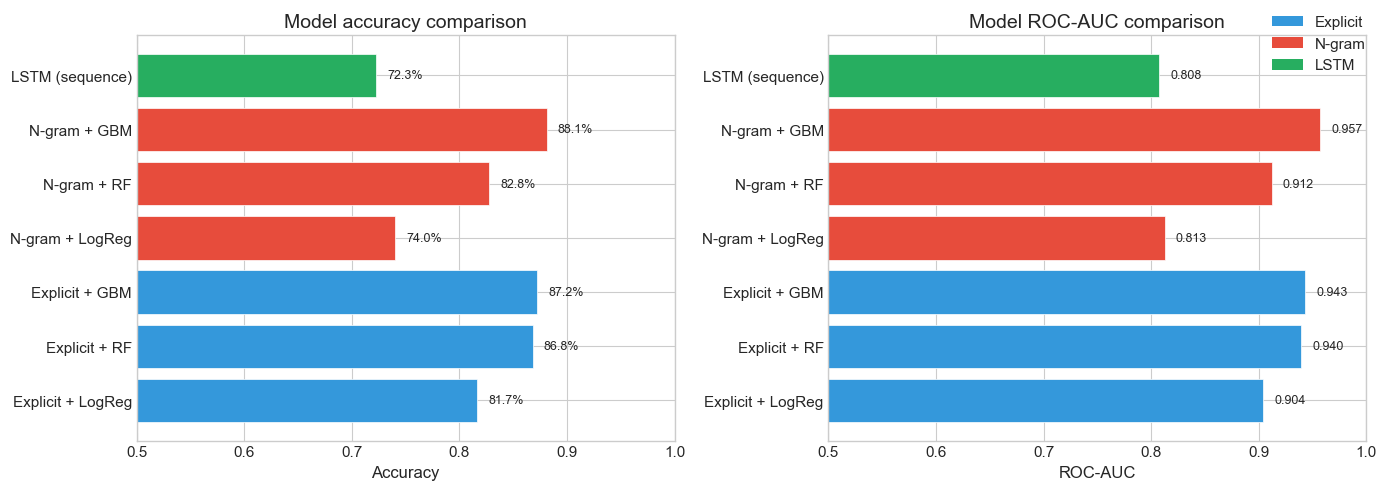

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

plot_data = []
for name, r in all_results.items():
    plot_data.append({
        'Model': name,
        'Approach': r['approach'],
        'Accuracy': r['accuracy'],
        'ROC-AUC': r['roc_auc']
    })
plot_df = pd.DataFrame(plot_data)

approach_colors = {'Explicit': COLORS['explicit'], 'N-gram': COLORS['ngram'], 'LSTM': COLORS['lstm']}
colors = [approach_colors[a] for a in plot_df['Approach']]

ax1 = axes[0]
bars1 = ax1.barh(plot_df['Model'], plot_df['Accuracy'], color=colors, edgecolor='white', linewidth=0.5)
ax1.set_xlabel('Accuracy')
ax1.set_title('Model accuracy comparison')
ax1.set_xlim(0.5, 1.0)
ax1.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5, label='Random baseline')

for bar, val in zip(bars1, plot_df['Accuracy']):
    ax1.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.1%}', va='center', fontsize=9)

ax2 = axes[1]
bars2 = ax2.barh(plot_df['Model'], plot_df['ROC-AUC'], color=colors, edgecolor='white', linewidth=0.5)
ax2.set_xlabel('ROC-AUC')
ax2.set_title('Model ROC-AUC comparison')
ax2.set_xlim(0.5, 1.0)
ax2.axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)

for bar, val in zip(bars2, plot_df['ROC-AUC']):
    ax2.text(val + 0.01, bar.get_y() + bar.get_height()/2, f'{val:.3f}', va='center', fontsize=9)

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor=c, label=a) for a, c in approach_colors.items()]
fig.legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(0.99, 0.99))

plt.tight_layout()
plt.show()

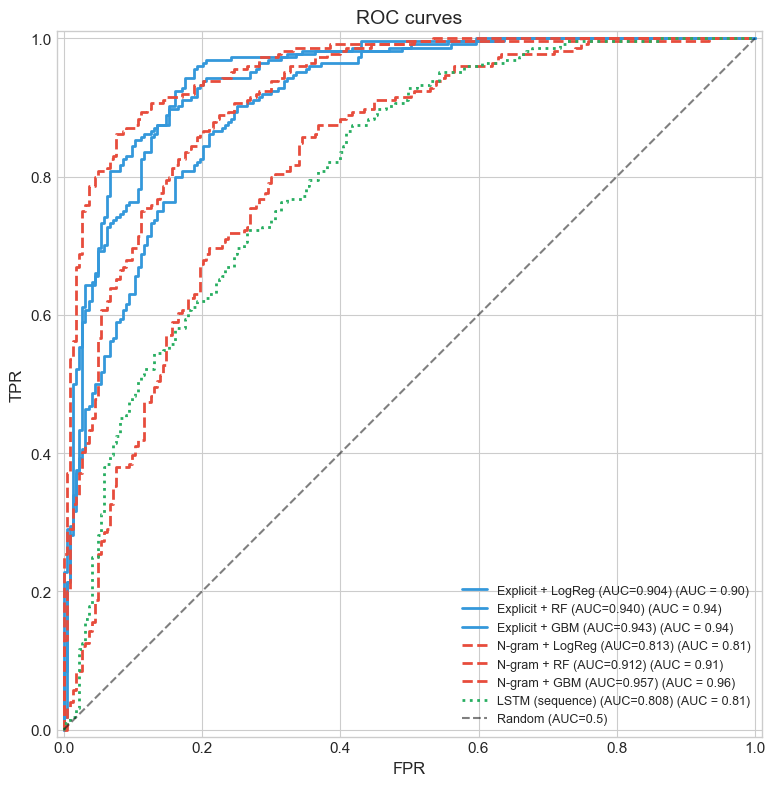

In [10]:
fig, ax = plt.subplots(figsize=(10, 8))

approach_colors = {'Explicit': COLORS['explicit'], 'N-gram': COLORS['ngram'], 'LSTM': COLORS['lstm']}
approach_styles = {'Explicit': '-', 'N-gram': '--', 'LSTM': ':'}

for name, r in all_results.items():
    approach = r['approach']
    RocCurveDisplay.from_predictions(
        y_test, r['y_proba'],
        name=f"{name} (AUC={r['roc_auc']:.3f})",
        ax=ax,
        color=approach_colors[approach],
        linestyle=approach_styles[approach],
        linewidth=2
    )

ax.plot([0, 1], [0, 1], 'k--', alpha=0.5, label='Random (AUC=0.5)')
ax.set_title('ROC curves', fontsize=14)
ax.legend(loc='lower right', fontsize=9)
ax.set_xlabel('FPR')
ax.set_ylabel('TPR')

plt.tight_layout()
plt.show()

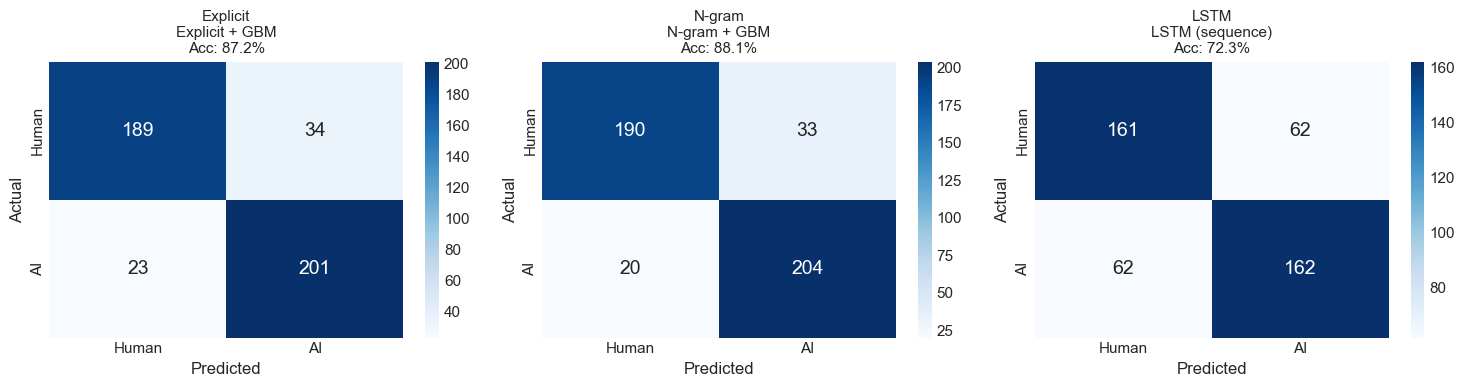

In [11]:
best_by_approach = {}
for approach in ['Explicit', 'N-gram', 'LSTM']:
    approach_models = {k: v for k, v in all_results.items() if v['approach'] == approach}
    if approach_models:
        best_name = max(approach_models.keys(), key=lambda k: approach_models[k]['roc_auc'])
        best_by_approach[approach] = (best_name, approach_models[best_name])

fig, axes = plt.subplots(1, len(best_by_approach), figsize=(5 * len(best_by_approach), 4))
if len(best_by_approach) == 1:
    axes = [axes]

for ax, (approach, (name, result)) in zip(axes, best_by_approach.items()):
    cm = confusion_matrix(y_test, result['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Human', 'AI'], yticklabels=['Human', 'AI'],
                annot_kws={'size': 14})
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')
    ax.set_title(f'{approach}\n{name}\nAcc: {result["accuracy"]:.1%}', fontsize=11)

plt.tight_layout()
plt.show()


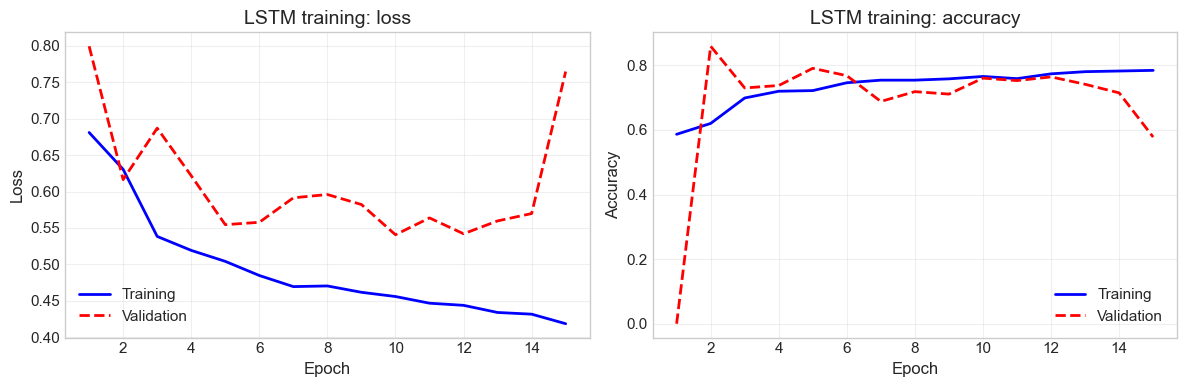

In [12]:
if TF_AVAILABLE and 'history' in all_results.get('LSTM (sequence)', {}):
    history = all_results['LSTM (sequence)']['history']
    
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    
    epochs = range(1, len(history['loss']) + 1)
    
    axes[0].plot(epochs, history['loss'], 'b-', linewidth=2, label='Training')
    axes[0].plot(epochs, history['val_loss'], 'r--', linewidth=2, label='Validation')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].set_title('LSTM training: loss')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    axes[1].plot(epochs, history['accuracy'], 'b-', linewidth=2, label='Training')
    axes[1].plot(epochs, history['val_accuracy'], 'r--', linewidth=2, label='Validation')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].set_title('LSTM training: accuracy')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()